# Direct-contact transmission - Ebola

**Case study: West Africa, 2014-2016 (WHO data).** Ebola virus disease spreads through direct contact with an infectious person or body - caregiving and funeral practices - with a high case fatality ratio. Two features drive the modelling: a **long latent period**, which sets the slow, months-long pace of the epidemic, and the fact that **isolating cases** is the intervention that actually worked. We fit a naive SIRD and a SEAIQR to the real cumulative WHO figures, show why the latent period is essential, then confirm the isolation story in the agent model [7][8].

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "simulation").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulation import compartmental as cm
from simulation import grid, plotting, metrics
from simulation.grid import ABMParams, InterventionSettings, RandomWalkModel, run_ensemble
from simulation.agents import State

plotting.use_house_style()

## The reported epidemic

In [2]:
# Real data: cumulative WHO-reported cases/deaths, each row from a primary
# WHO Disease Outbreak News / ECDC epidemiological update.
DATA = pathlib.Path.cwd() / "data" / "ebola_west_africa_who_milestones.csv"
who = pd.read_csv(DATA, comment="#", parse_dates=["date"])
who["day"] = (who["date"] - pd.Timestamp("2014-01-01")).dt.days   # days since 1 Jan 2014
who

,date,cumulative_cases,cumulative_deaths,source,day
0,2014-07-23,1201,672,WHO DON 27 Jul 2014,203
1,2014-08-26,3069,1552,WHO DON / ECDC 28 Aug 2014,237
2,2014-10-05,8032,3865,ECDC 9 Oct 2014,277
3,2014-10-19,9936,4877,ECDC 23 Oct 2014,291
4,2014-12-17,18603,6915,ECDC 18 Dec 2014,350
5,2015-01-29,22136,8833,ECDC 29 Jan 2015,393
6,2015-11-18,28598,11299,ECDC 23 Nov 2015,686


reported CFR at each milestone: [0.56, 0.51, 0.48, 0.49, 0.37, 0.4, 0.4]


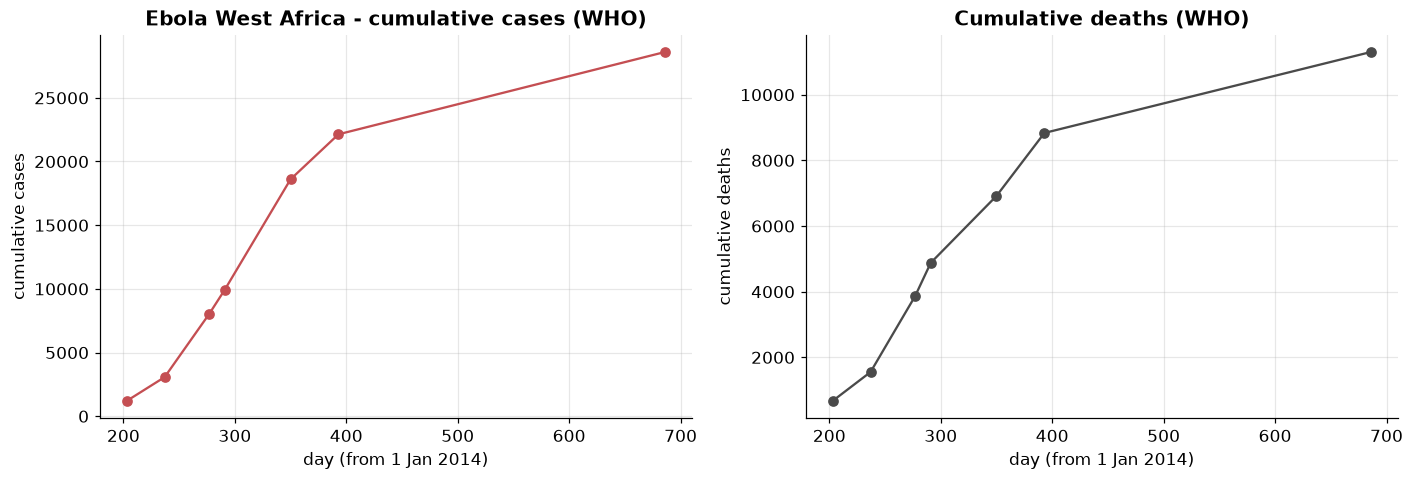

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(who["day"], who["cumulative_cases"], "o-", color=plotting.PALETTE["I"])
a1.set_xlabel("day (from 1 Jan 2014)"); a1.set_ylabel("cumulative cases")
a1.set_title("Ebola West Africa - cumulative cases (WHO)")
a2.plot(who["day"], who["cumulative_deaths"], "o-", color=plotting.PALETTE["D"])
a2.set_xlabel("day (from 1 Jan 2014)"); a2.set_ylabel("cumulative deaths")
a2.set_title("Cumulative deaths (WHO)")
plt.tight_layout()
print("reported CFR at each milestone:",
      (who["cumulative_deaths"] / who["cumulative_cases"]).round(2).tolist())

## Natural history

In [4]:
# Natural history. The key feature is a long generation time: an ~11 day
# incubation on top of an ~7 day infectious period, which is why the epidemic
# built up over many months. Transmission is close-contact (caregiving,
# funerals), so the effective mixing population is far below the ~22 M living in
# the three countries.
sigma = 1 / 11.0        # incubation rate (~11 day latent period) [8]
gamma = 1 / 7.0         # recovery rate (~7 day infectious period)
rho, eta = 0.7, 0.3     # symptomatic fraction; low asymptomatic infectiousness
CFR = 0.40              # settled reported case fatality ratio (~11,299 / 28,598)

# For the naive SIRD comparison we give it a disease-death rate too.
cfr_clin = 0.6
mu = cfr_clin * gamma / (1 - cfr_clin)

doy = who["day"].values
obs = who["cumulative_cases"].values
HORIZON = 760

## Fitting to the WHO milestones

We hold the natural-history rates fixed and fit each model's effective
population, R0 and onset day to the cumulative WHO figures. The question is which
structure reproduces the shape of a slow, months-long epidemic.

In [5]:
def cumulative(model, Neff, t0):
    df = model.simulate(model._y0, HORIZON, HORIZON + 1)
    cum = Neff - df["S"].values
    return np.array([np.interp(d - t0, np.arange(HORIZON + 1), cum) if d >= t0 else 0.0
                     for d in doy])

def fit(build_model, R0_grid, N_grid, t0_grid):
    best = None
    for R0 in R0_grid:
        for Neff in N_grid:
            model = build_model(Neff, R0)
            model._y0 = model_y0(model, Neff)
            for t0 in t0_grid:
                pred = cumulative(model, Neff, t0)
                err = np.mean(np.abs(pred - obs) / obs)
                if best is None or err < best["err"]:
                    best = {"err": err, "R0": R0, "Neff": Neff, "t0": t0, "pred": pred}
    return best

def model_y0(model, Neff):
    # SEAIQR state has 6 compartments, SIRD has 4
    return [Neff - 5, 0, 0, 5, 0, 0] if len(model.compartments) == 6 else [Neff - 5, 5, 0, 0]

def seaiqr(Neff, R0):
    beta = R0 * gamma / (eta * (1 - rho) + rho)
    return cm.SEAIQR(cm.SEAIQRParams(beta, sigma, gamma, rho=rho, eta=eta, q=0.0), Neff)

def sird(Neff, R0):
    return cm.SIRD(cm.SIRDParams(R0 * (gamma + mu), gamma, mu), Neff)

R0_grid = np.round(np.arange(1.2, 2.01, 0.1), 2)
N_grid = np.arange(30_000, 60_001, 4_000)
t0_grid = range(40, 201, 10)   # wide enough for each model to find its own best onset

best_se = fit(seaiqr, R0_grid, N_grid, t0_grid)
best_sd = fit(sird, R0_grid, N_grid, t0_grid)
onset = lambda t0: (pd.Timestamp("2014-01-01") + pd.Timedelta(days=int(t0))).date()
print(f"SEAIQR:  R0={best_se['R0']:.1f}  N={best_se['Neff']:,}  onset {onset(best_se['t0'])}  "
      f"mean rel err={best_se['err']:.2f}")
print(f"SIRD  :  R0={best_sd['R0']:.1f}  N={best_sd['Neff']:,}  onset {onset(best_sd['t0'])}  "
      f"mean rel err={best_sd['err']:.2f}")
print(f"(WHO first notified the outbreak on 23 Mar 2014 -> day 82)")

SEAIQR:  R0=1.6  N=38,000  onset 2014-03-02  mean rel err=0.06
SIRD  :  R0=1.2  N=58,000  onset 2014-07-10  mean rel err=0.36
(WHO first notified the outbreak on 23 Mar 2014 -> day 82)


Cumulative cases at each WHO report date:

In [6]:
table = pd.DataFrame({
    "date": who["date"].dt.date,
    "WHO cases": obs,
    "SEAIQR": best_se["pred"].round().astype(int),
    "ratio": (best_se["pred"] / obs).round(2),
    "SIRD": best_sd["pred"].round().astype(int),
})
table

,date,WHO cases,SEAIQR,ratio,SIRD
0,2014-07-23,1201,1301,1.08,51
1,2014-08-26,3069,3268,1.06,801
2,2014-10-05,8032,8162,1.02,8007
3,2014-10-19,9936,10511,1.06,12172
4,2014-12-17,18603,19605,1.05,18011
5,2015-01-29,22136,22706,1.03,18200
6,2015-11-18,28598,24401,0.85,18214


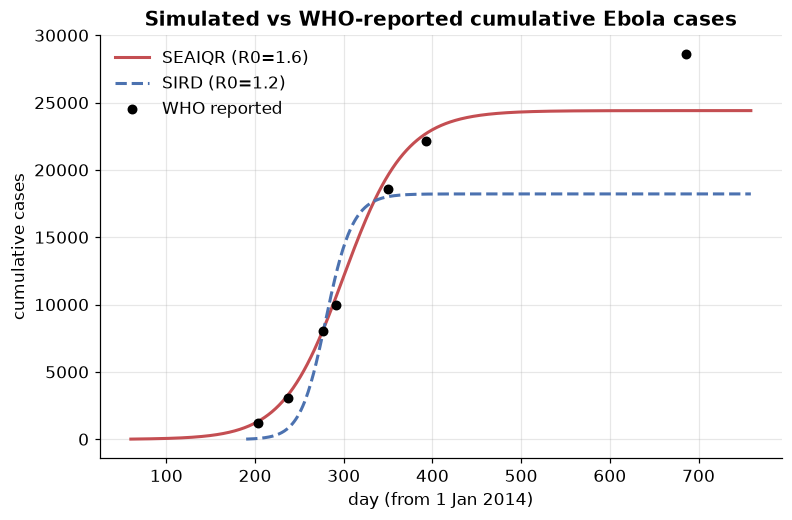

In [7]:
def trajectory(build_model, best):
    m = build_model(best["Neff"], best["R0"]); m._y0 = model_y0(m, best["Neff"])
    df = m.simulate(m._y0, HORIZON, HORIZON + 1)
    cum = best["Neff"] - df["S"].values
    t = np.arange(best["t0"], HORIZON)
    return t, np.interp(t - best["t0"], np.arange(HORIZON + 1), cum)

fig, ax = plt.subplots()
t, y = trajectory(seaiqr, best_se)
ax.plot(t, y, color=plotting.PALETTE["I"], lw=2, label=f"SEAIQR (R0={best_se['R0']:.1f})")
t, y = trajectory(sird, best_sd)
ax.plot(t, y, color=plotting.PALETTE["S"], lw=2, ls="--", label=f"SIRD (R0={best_sd['R0']:.1f})")
ax.scatter(doy, obs, color=plotting.PALETTE["data"], s=30, zorder=5, label="WHO reported")
ax.set_xlabel("day (from 1 Jan 2014)"); ax.set_ylabel("cumulative cases")
ax.set_title("Simulated vs WHO-reported cumulative Ebola cases")
ax.legend();

### Death toll, from the SEAIQR case trajectory times the reported CFR:

In [8]:
# Deaths from the SEAIQR case trajectory via the settled reported CFR.
deaths_table = pd.DataFrame({
    "date": who["date"].dt.date,
    "WHO deaths": who["cumulative_deaths"].values,
    "model deaths (CFR=0.40)": (best_se["pred"] * CFR).round().astype(int),
    "WHO reported CFR": (who["cumulative_deaths"] / obs).round(2),
})
deaths_table

,date,WHO deaths,model deaths (CFR=0.40),WHO reported CFR
0,2014-07-23,672,520,0.56
1,2014-08-26,1552,1307,0.51
2,2014-10-05,3865,3265,0.48
3,2014-10-19,4877,4204,0.49
4,2014-12-17,6915,7842,0.37
5,2015-01-29,8833,9082,0.40
6,2015-11-18,11299,9760,0.40


## Isolation as the control lever

For Ebola the decisive intervention was isolating cases quickly (treatment units,
safe burials, contact tracing). In the model that is the rate `q`; increasing it
drives the reproduction number down past the critical threshold of 1.

isolation rate q = 0.0   ->  R0 = 1.60
isolation rate q = 0.08  ->  R0 = 1.09
isolation rate q = 0.15  ->  R0 = 0.87  <- below 1, outbreak cannot sustain
isolation rate q = 0.3   ->  R0 = 0.64  <- below 1, outbreak cannot sustain


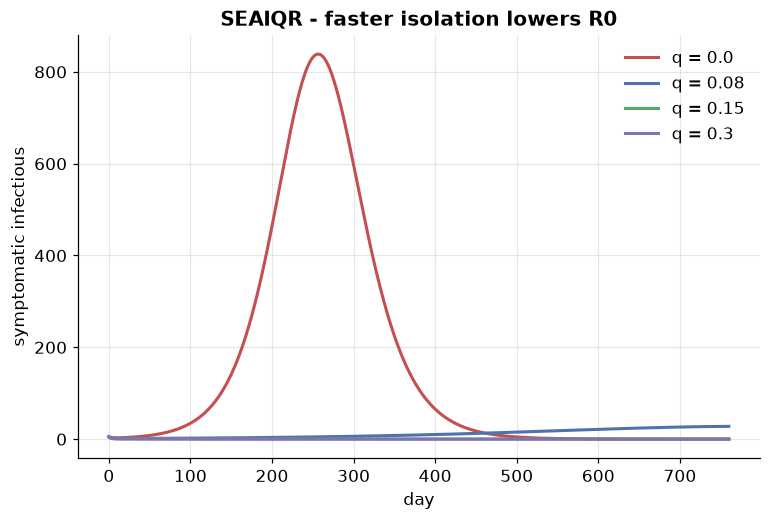

In [9]:
beta_se = best_se["R0"] * gamma / (eta * (1 - rho) + rho)
Neff = best_se["Neff"]
iso_curves = {}
for q in [0.0, 0.08, 0.15, 0.30]:
    m = cm.SEAIQR(cm.SEAIQRParams(beta_se, sigma, gamma, rho=rho, eta=eta, q=q), Neff)
    out = m.simulate([Neff - 5, 0, 0, 5, 0, 0], HORIZON, HORIZON + 1)
    iso_curves[f"q = {q}"] = (out.index, out["I"])
    flag = "  <- below 1, outbreak cannot sustain" if m.r0() < 1 else ""
    print(f"isolation rate q = {q:<5} ->  R0 = {m.r0():.2f}{flag}")

plotting.plot_scenarios(iso_curves, title="SEAIQR - faster isolation lowers R0",
                        ylabel="symptomatic infectious")
plt.gca().set_xlabel("day");

## Agent-based direct-contact spread

Direct contact is the strictest rule: a susceptible can only be
infected by an infectious agent in the same cell. Because an isolated source
then stops sharing cells altogether, isolation is far more effective here than
for an airborne disease - which is exactly why contact tracing worked for Ebola.

no isolation           attack rate = 0.72   peak = 369


isolate 70% of cases   attack rate = 0.25   peak = 115


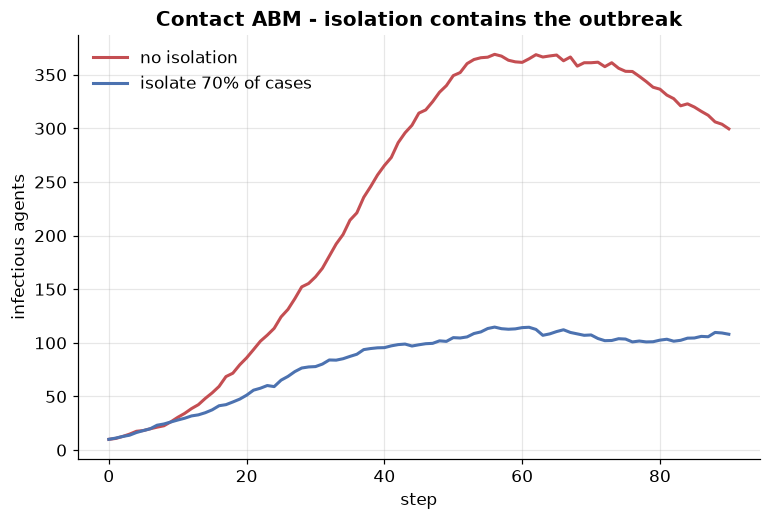

In [10]:
abm_params = ABMParams(infect_prob=0.25, recovery_prob=0.08, step_prob=0.8, cfr=0.6)
GRID, NAG, STEPS, RUNS = 50, 3000, 90, 6
common = dict(grid_size=GRID, n_agents=NAG, mechanism="contact",
              params=abm_params, n_infected=10, base_seed=50)

abm_curves = {}
for name, iv in {
    "no isolation": None,
    "isolate 70% of cases": InterventionSettings(quarantine_fraction=0.7, quarantine_delay=1),
}.items():
    mean, _ = run_ensemble(RUNS, STEPS, interventions=iv, **common)
    abm_curves[name] = (np.arange(mean.shape[0]), mean[:, State.INFECTIOUS])
    print(f"{name:22s} attack rate = {1 - mean[-1, State.SUSCEPTIBLE] / NAG:.2f}   "
          f"peak = {mean[:, State.INFECTIOUS].max():.0f}")

plotting.plot_scenarios(abm_curves, title="Contact ABM - isolation contains the outbreak",
                        ylabel="infectious agents")
plt.gca().set_xlabel("step");

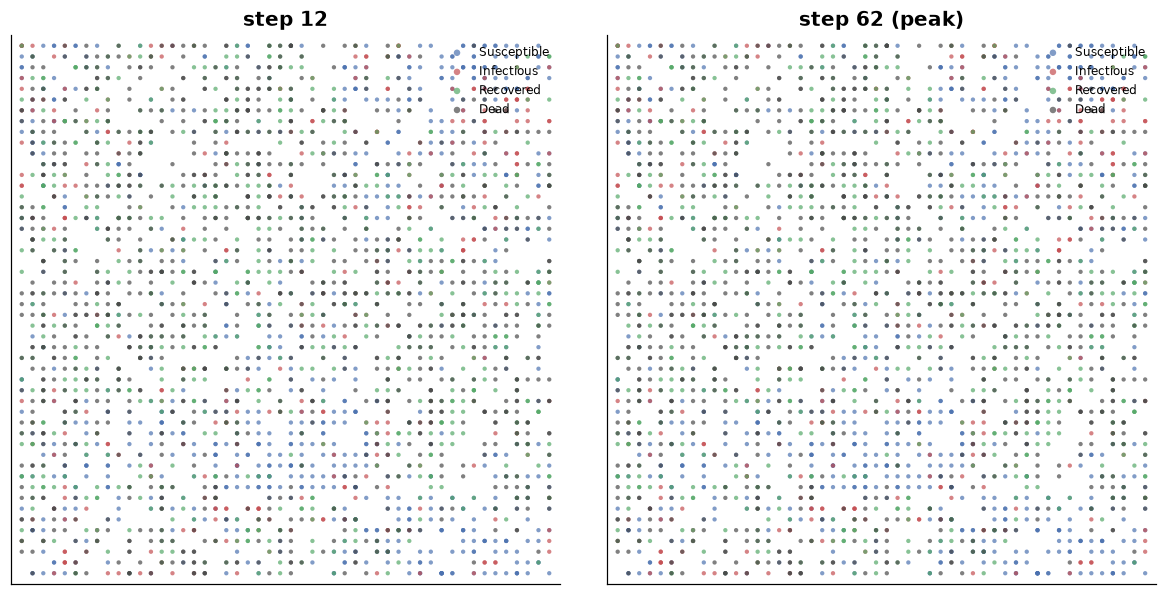

In [11]:
model = RandomWalkModel(GRID, NAG, "contact", abm_params, n_infected=10, seed=50)
frames = list(model.run(STEPS))
peak_step = int(np.argmax([f.counts[State.INFECTIOUS] for f in frames]))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5.4))
plotting.plot_grid_snapshot(frames[12].population, GRID, ax=a1, title="step 12")
plotting.plot_grid_snapshot(frames[peak_step].population, GRID, ax=a2,
                            title=f"step {peak_step} (peak)")
plt.tight_layout();

**Criticising the fit.** With the ~11 day incubation in place, SEAIQR reproduces the real cumulative trajectory strikingly well through the explosive phase (within ~10% at every 2014 milestone), and - without being told - places the epidemic's onset within a few weeks of the actual WHO notification date (23 March 2014). The naive SIRD cannot match the *shape*: its generation time is just the infectious period, so to fit the steep Aug-Dec rise it needs a late onset (missing the July milestone almost entirely) and then saturates, settling well short of the year-end total - a mean error of ~36% against SEAIQR's ~6%. The fitted R0 of about 1.6 sits squarely inside the published 1.5-2.0 range for this epidemic.

The honest failure is the **2015 tail**: the single-wave model plateaus near its final size while the real epidemic dragged on for another year of low-level transmission and flare-ups (persistent chains, reintroductions), which a single well-mixed wave cannot represent. A further caveat lives in the data: the *reported* CFR falls from ~0.56 to ~0.40 across the milestones as case outcomes are recorded, so a single constant CFR over- then under-states the early death toll.

**Read-out.** Ebola shows why the *timescale* structure of a model matters: the naive SIRD recovers R0 and rough magnitude but gets the shape wrong, saturating in weeks when the real epidemic climbed for months; restoring the latent period (SEAIQR) fixes it and matches the real WHO cumulative counts to ~10%. Isolation is the effective control - an isolation rate near 0.15 pulls R0 below 1 - and in the direct-contact agent model isolating cases collapses the attack rate, a far stronger effect than the same measure had for the airborne disease, because removing a contact case removes its transmission route entirely.

*Limitations.* Single effective mixing population (real spread was a metapopulation across three countries with a long 2015 tail); constant parameters (no safe-burial or behaviour change over time); a reported CFR that drifts over the epidemic; and cumulative-only surveillance data (`data/README.md`).